In [1]:
from google.colab import auth; auth.authenticate_user()
from google.colab import drive; drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 62.3 MB/s eta 0:00:00
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import mne
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
from sklearn.preprocessing import RobustScaler

In [2]:
##Importa dataset da Kaggle
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yosftag/open-nuro-dataset")

print("Path to dataset files:", path)

100%|██████████| 4.17G/4.17G [00:51<00:00, 86.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/yosftag/open-nuro-dataset/versions/1


In [3]:
import os
tsv_path = "/root/.cache/kagglehub/datasets/yosftag/open-nuro-dataset/versions/1/dataset/participants.tsv"
print(tsv_path)
participants = pd.read_csv(tsv_path, sep='\t')
print(participants)
mappa = pd.read_csv(tsv_path, sep='\t', dtype={"participant_id": str, "Group": str})



/root/.cache/kagglehub/datasets/yosftag/open-nuro-dataset/versions/1/dataset/participants.tsv
   participant_id Gender  Age Group  MMSE
0         sub-001      F   57     A    16
1         sub-002      F   78     A    22
2         sub-003      M   70     A    14
3         sub-004      F   67     A    20
4         sub-005      M   70     A    22
..            ...    ...  ...   ...   ...
83        sub-084      F   71     F    24
84        sub-085      M   64     F    26
85        sub-086      M   49     F    26
86        sub-087      M   73     F    24
87        sub-088      M   55     F    24

[88 rows x 5 columns]


Using matplotlib as 2D backend.


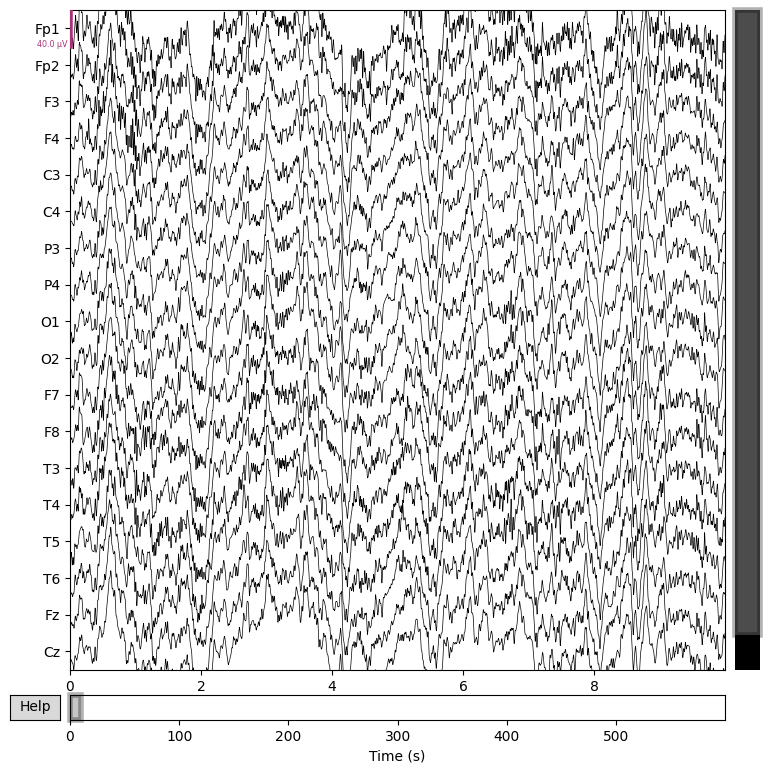

<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2, F7, F8, T3, T4, T5, ...
 chs: 19 EEG
 custom_ref_applied: False
 dig: 22 items (3 Cardinal, 19 EEG)
 highpass: 0.0 Hz
 lowpass: 250.0 Hz
 meas_date: unspecified
 nchan: 19
 projs: []
 sfreq: 500.0 Hz
>


In [4]:

file_path = '/root/.cache/kagglehub/datasets/yosftag/open-nuro-dataset/versions/1/dataset/derivatives/sub-001/eeg/sub-001_task-eyesclosed_eeg.set'
raw = mne.io.read_raw_eeglab(file_path, preload=True)
raw.plot(n_channels=18)
print(raw.info)

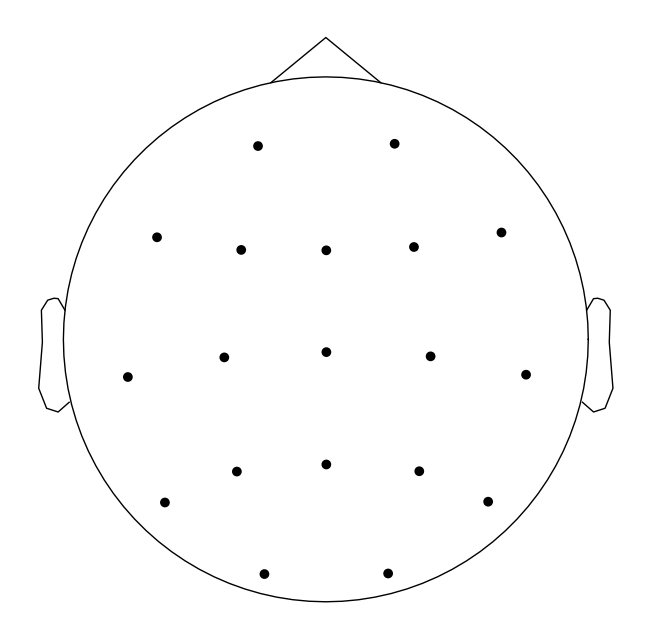

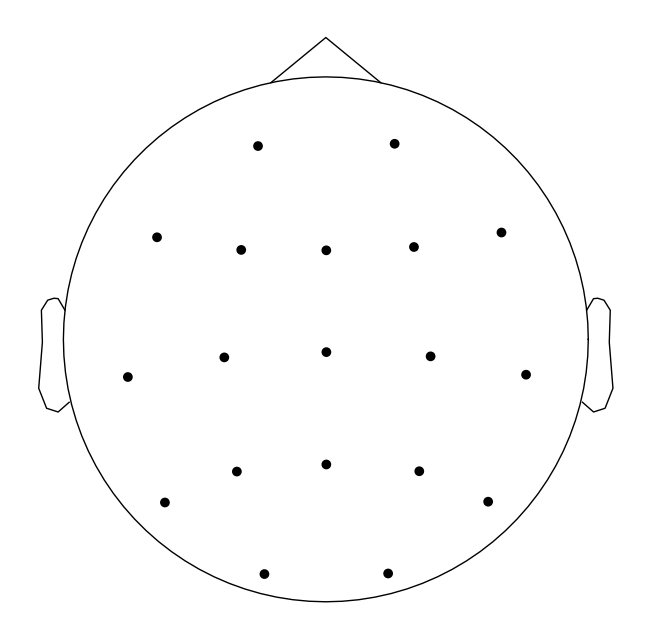

In [ ]:
raw.plot_sensors(kind='topomap', ch_type='eeg', sphere=(0,0,0,0.12))

Cerco delle feature che possono essere maggiormente correlate rispetto ad altre. Dal plot il range tra 8-10 Hz e  35-40 Hz ha un coefficiente di Pearson più elevato in modulo assoluto

Verifying 'Group' column after re-preparation:


,count
Group,
1,179360
0,148485
2,101650


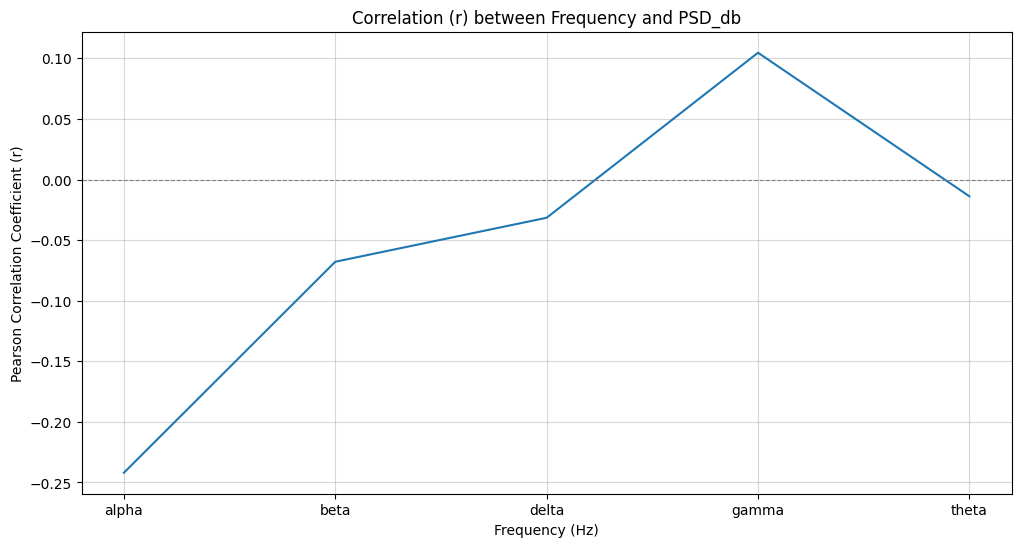

In [5]:
from scipy.stats import pearsonr

#carico dataframe da file .parquet
df = pd.read_parquet("/content/drive/MyDrive/psd_bands.parquet")

# Merge con mappa per ottenere la colonna Group
df = df.merge(mappa, on='participant_id', how='left')

# Converto la stringa gruppo in float
df['Group'] = df['Group'].map({'A': 1, 'F': 2, 'C': 0})

# Calcolo le psdb in dB
df['psd_db'] = 10 * np.log10(df['psd_band_mean'])

print("Verifying 'Group' column after re-preparation:")
display(df['Group'].value_counts(dropna=False))

# Now proceed with correlation calculation
results = []

for f, d in df.groupby('band'):
    # Only calculate correlation if there are at least two unique groups present
    if d['Group'].nunique() > 1:
        r, p = pearsonr(d['psd_db'], d['Group'])
        results.append((f, r, p))

corr_df = pd.DataFrame(results, columns=['band', 'r', 'p'])

plt.figure(figsize=(12, 6))
sns.lineplot(data=corr_df, x='band', y='r')
plt.title('Correlation (r) between Frequency and PSD_db')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Pearson Correlation Coefficient (r)')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.grid(True, which='both', ls='-', alpha=0.5)
plt.show()


In [6]:
##Considero solo le frequenze con correlazione più alta
bands_of_interest = ['alpha', 'gamma','beta','delta']
df_feat = df[df['band'].isin(bands_of_interest)].copy()


In [7]:
#Creo un nuovo dataframe con le feauture che mi interessano
df_feat_subj = (
    df_feat.groupby(['participant_id', 'channel', 'band', 'Gender', 'Age', 'Group'])['psd_band_mean']
    .mean()
    .reset_index()
)
df_feat_subj['psd_band_mean_dB'] = 10 * np.log10(df_feat_subj['psd_band_mean'])
wide = df_feat_subj.pivot_table(
    index=['participant_id', 'Gender', 'Age', 'Group'],
    columns=['channel', 'band'],
    values='psd_band_mean_dB'
)
wide.columns = [f"{ch}_{band}" for ch, band in wide.columns]
wide = wide.reset_index()
wide.head()

,participant_id,Gender,Age,Group,C3_alpha,C3_beta,C3_delta,C3_gamma,C4_alpha,C4_beta,...,T4_delta,T4_gamma,T5_alpha,T5_beta,T5_delta,T5_gamma,T6_alpha,T6_beta,T6_delta,T6_gamma
0,sub-001,F,57,1,-116.810304,-122.635089,-98.819466,-128.373043,-116.824522,-122.595310,...,-98.775246,-125.171069,-115.525928,-120.738210,-98.667556,-123.589724,-116.056594,-121.888527,-98.699724,-126.804803
1,sub-002,F,78,1,-115.670824,-122.451681,-99.256463,-128.275230,-115.867036,-122.481699,...,-99.195766,-123.189898,-110.073027,-120.531519,-99.145405,-126.979896,-110.162612,-120.820023,-99.162871,-126.880784
2,sub-003,M,70,1,-113.735699,-122.634447,-100.114606,-129.458677,-113.646482,-122.635080,...,-99.973110,-128.100485,-108.738871,-121.528401,-99.755890,-127.993132,-106.447941,-121.230056,-99.785247,-128.526152
3,sub-004,F,67,1,-116.614101,-122.272994,-98.829242,-125.984987,-116.623647,-122.382767,...,-98.691156,-120.848738,-116.385142,-121.925579,-98.644650,-125.285168,-116.373999,-121.731825,-98.641646,-124.460461
4,sub-005,M,70,1,-116.468614,-122.409957,-98.970750,-127.404669,-116.365848,-122.326533,...,-98.884935,-124.140572,-114.510357,-120.611225,-98.783329,-125.236084,-114.784199,-120.386650,-98.863322,-125.323514


In [8]:
df_feat_subj.head()

,participant_id,channel,band,Gender,Age,Group,psd_band_mean,psd_band_mean_dB
0,sub-001,C3,alpha,F,57,1,2.084345e-12,-116.810304
1,sub-001,C3,beta,F,57,1,5.451187e-13,-122.635089
2,sub-001,C3,delta,F,57,1,1.312361e-10,-98.819466
3,sub-001,C3,gamma,F,57,1,1.454439e-13,-128.373043
4,sub-001,C4,alpha,F,57,1,2.077533e-12,-116.824522


In [9]:
wide.head()


,participant_id,Gender,Age,Group,C3_alpha,C3_beta,C3_delta,C3_gamma,C4_alpha,C4_beta,...,T4_delta,T4_gamma,T5_alpha,T5_beta,T5_delta,T5_gamma,T6_alpha,T6_beta,T6_delta,T6_gamma
0,sub-001,F,57,1,-116.810304,-122.635089,-98.819466,-128.373043,-116.824522,-122.595310,...,-98.775246,-125.171069,-115.525928,-120.738210,-98.667556,-123.589724,-116.056594,-121.888527,-98.699724,-126.804803
1,sub-002,F,78,1,-115.670824,-122.451681,-99.256463,-128.275230,-115.867036,-122.481699,...,-99.195766,-123.189898,-110.073027,-120.531519,-99.145405,-126.979896,-110.162612,-120.820023,-99.162871,-126.880784
2,sub-003,M,70,1,-113.735699,-122.634447,-100.114606,-129.458677,-113.646482,-122.635080,...,-99.973110,-128.100485,-108.738871,-121.528401,-99.755890,-127.993132,-106.447941,-121.230056,-99.785247,-128.526152
3,sub-004,F,67,1,-116.614101,-122.272994,-98.829242,-125.984987,-116.623647,-122.382767,...,-98.691156,-120.848738,-116.385142,-121.925579,-98.644650,-125.285168,-116.373999,-121.731825,-98.641646,-124.460461
4,sub-005,M,70,1,-116.468614,-122.409957,-98.970750,-127.404669,-116.365848,-122.326533,...,-98.884935,-124.140572,-114.510357,-120.611225,-98.783329,-125.236084,-114.784199,-120.386650,-98.863322,-125.323514


In [10]:
#Creo dataframe con le feauture per il mio modello ML e uno con i target
X_full_features = wide.drop(columns=['participant_id', 'Group','Gender','Age'])
y_full = wide['Group']
# Stampa le dimensioni dei nuovi set di dati
print("Shape di X_full_features (features complete):".ljust(40), X_full_features.shape)
print("Shape di y_full (target completo):".ljust(40), y_full.shape)

# Visualizza le prime righe delle feature e del target
print("\nPrime 5 righe di X_full_features:")
display(X_full_features.head())
print("\nPrime 5 righe di y_full:")
display(y_full.head())

Shape di X_full_features (features complete): (88, 76)
Shape di y_full (target completo):       (88,)

Prime 5 righe di X_full_features:


,C3_alpha,C3_beta,C3_delta,C3_gamma,C4_alpha,C4_beta,C4_delta,C4_gamma,Cz_alpha,Cz_beta,...,T4_delta,T4_gamma,T5_alpha,T5_beta,T5_delta,T5_gamma,T6_alpha,T6_beta,T6_delta,T6_gamma
0,-116.810304,-122.635089,-98.819466,-128.373043,-116.824522,-122.595310,-98.817794,-128.088659,-116.781564,-122.539178,...,-98.775246,-125.171069,-115.525928,-120.738210,-98.667556,-123.589724,-116.056594,-121.888527,-98.699724,-126.804803
1,-115.670824,-122.451681,-99.256463,-128.275230,-115.867036,-122.481699,-99.304009,-128.247251,-114.657567,-121.880236,...,-99.195766,-123.189898,-110.073027,-120.531519,-99.145405,-126.979896,-110.162612,-120.820023,-99.162871,-126.880784
2,-113.735699,-122.634447,-100.114606,-129.458677,-113.646482,-122.635080,-100.006415,-129.392555,-114.315506,-122.456413,...,-99.973110,-128.100485,-108.738871,-121.528401,-99.755890,-127.993132,-106.447941,-121.230056,-99.785247,-128.526152
3,-116.614101,-122.272994,-98.829242,-125.984987,-116.623647,-122.382767,-98.809493,-126.357115,-116.551505,-122.177021,...,-98.691156,-120.848738,-116.385142,-121.925579,-98.644650,-125.285168,-116.373999,-121.731825,-98.641646,-124.460461
4,-116.468614,-122.409957,-98.970750,-127.404669,-116.365848,-122.326533,-98.974231,-127.518209,-116.561822,-122.407873,...,-98.884935,-124.140572,-114.510357,-120.611225,-98.783329,-125.236084,-114.784199,-120.386650,-98.863322,-125.323514



Prime 5 righe di y_full:


,Group
0,1
1,1
2,1
3,1
4,1


In [11]:
#Divido il dataset in 70% per training e 30% per test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_full_features, y_full,
    test_size=0.3,
    random_state=42,
    stratify=y_full
)
print("Train shape X:", X_train.shape, " y:", y_train.shape)
print("Test shape  X:", X_test.shape,  " y:", y_test.shape)

print("Distribuzione training:")
print(y_train.value_counts(normalize=True))

print("Distribuzione test:")
print(y_test.value_counts(normalize=True))

Train shape X: (61, 76)  y: (61,)
Test shape  X: (27, 76)  y: (27,)
Distribuzione training:
Group
1    0.409836
0    0.327869
2    0.262295
Name: proportion, dtype: float64
Distribuzione test:
Group
1    0.407407
0    0.333333
2    0.259259
Name: proportion, dtype: float64


In [12]:
def squared_inverse_distance(distances):
    return 1.0 / (distances**2 + 1e-12)

In [13]:
def gausssian (distances, sigma = 1.0):
    return np.exp(-distances**2)/(2*sigma**2)

Migliori parametri k-NN con features significative: {'knn__algorithm': 'brute', 'knn__metric': 'cosine', 'knn__n_neighbors': 7, 'knn__weights': <function gausssian at 0x7f561a12a3e0>}
ROC AUC (test) con features significative: 0.7721661054994389


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [0.52676126 0.52676126 0.5365883  0.58440176 0.59177349 0.57745551
 0.61886344 0.59411195 0.64602633 0.5043739  0.5043739         nan
 0.54308732 0.53993256        nan 0.53497144 0.53067931        nan]
  warnings.warn(


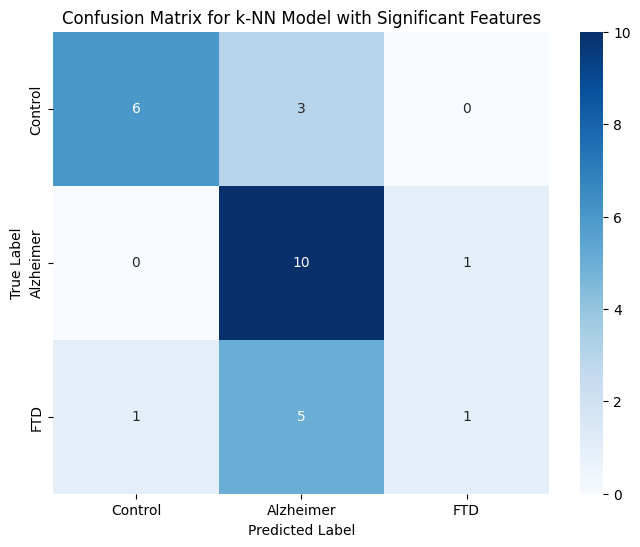

Classification Report con features significative:
               precision    recall  f1-score   support

     Control       0.86      0.67      0.75         9
   Alzheimer       0.56      0.91      0.69        11
         FTD       0.50      0.14      0.22         7

    accuracy                           0.63        27
   macro avg       0.64      0.57      0.55        27
weighted avg       0.64      0.63      0.59        27



In [14]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, Normalizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Define the pipeline for KNN with scaling
pipe_knn_significant = Pipeline(
    [('scaler', StandardScaler()), ('knn', KNeighborsClassifier())]
)

# Define the parameter grid for KNN
param_knn_significant = {
    'knn__n_neighbors': [2,4,7],
    'knn__weights': ['distance', squared_inverse_distance,gausssian ],
    'knn__metric': ['cosine','euclidean'],
    'knn__algorithm': ['brute']
}

# Initialize StratifiedGroupKFold for cross-validation
sgkf_significant = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=42)

# Perform GridSearchCV
grid_knn_significant = GridSearchCV(
    estimator=pipe_knn_significant,
    param_grid=param_knn_significant,
    scoring="roc_auc_ovr",
    cv=sgkf_significant,


    n_jobs=-1,
    refit=True,
    verbose=0,
)

# Fit the GridSearchCV object to the training data
grid_knn_significant.fit(X_train, y_train, groups=wide.loc[X_train.index, 'participant_id']  )

print(
    "Migliori parametri k-NN con features significative:",
    grid_knn_significant.best_params_,
)

# Predict on the test set using the best estimator
y_pred_knn_significant = grid_knn_significant.predict(X_test)
y_proba_knn_significant = grid_knn_significant.predict_proba(X_test)

# Evaluate ROC AUC score
roc_auc_significant = roc_auc_score(
    y_test, y_proba_knn_significant, multi_class='ovr', average='macro'
)
print("ROC AUC (test) con features significative:", roc_auc_significant)

# Generate and plot the confusion matrix
cm_significant = confusion_matrix(y_test, y_pred_knn_significant)

class_names = ['Control', 'Alzheimer', 'FTD']

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_significant,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title('Confusion Matrix for k-NN Model with Significant Features')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Print classification report for more detailed metrics
print(
    "Classification Report con features significative:\n",
    classification_report(
        y_test, y_pred_knn_significant, target_names=class_names
    ),
)


Migliori parametri k-NN con features significative: {'svc__C': 1, 'svc__class_weight': 'balanced', 'svc__degree': 2, 'svc__gamma': 'auto', 'svc__kernel': 'rbf'}
ROC AUC (test) con features significative: 0.6791873764095987


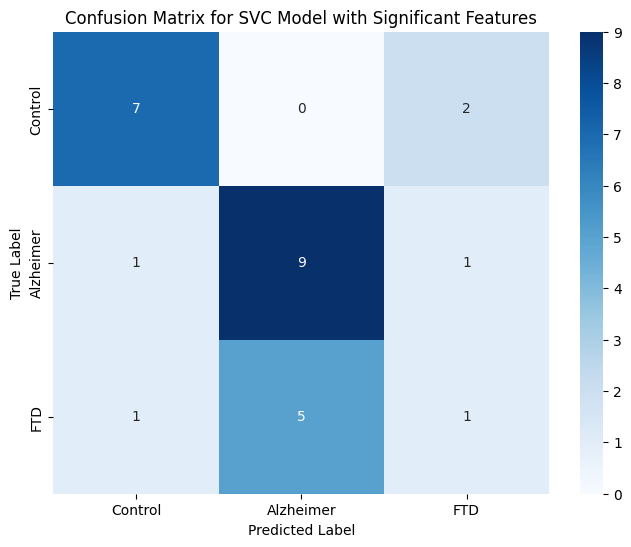

Classification Report con features significative:
               precision    recall  f1-score   support

     Control       0.78      0.78      0.78         9
   Alzheimer       0.64      0.82      0.72        11
         FTD       0.25      0.14      0.18         7

    accuracy                           0.63        27
   macro avg       0.56      0.58      0.56        27
weighted avg       0.59      0.63      0.60        27



In [15]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC




pipe_svc_significant = Pipeline(
    [('scaler', StandardScaler()), ('svc', SVC(probability=True))]
)

# Define the parameter grid for SVC

param_svc_significant = {
    'svc__kernel': ['poly','rbf'],
    'svc__C': [0.1,1,10,15, 100],
    'svc__gamma': ['scale', 'auto'],
    'svc__class_weight': [ 'balanced',None],
    'svc__degree': [2] # #Uso una funzione quadratica, grado 2
}



# Initialize StratifiedGroupKFold for cross-validation
sgkf_significant = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=42)

# Perform GridSearchCV
grid_svc_significant = GridSearchCV(
    estimator=pipe_svc_significant,
    param_grid=param_svc_significant,
    scoring="roc_auc_ovr",
    cv=sgkf_significant.split(
        X_train, y_train, groups=wide.loc[X_train.index, 'participant_id']
    ),
    n_jobs=-1,
    refit=True,
    verbose=0,
)

# Fit the GridSearchCV object to the training data
grid_svc_significant.fit(X_train, y_train, groups=wide.loc[X_train.index, 'participant_id'] )

print(
    "Migliori parametri k-NN con features significative:",
    grid_svc_significant.best_params_,
)

# Predict on the test set using the best estimator
y_pred_svc_significant = grid_svc_significant.predict(X_test)
y_proba_svc_significant = grid_svc_significant.predict_proba(X_test)

# Evaluate ROC AUC score
roc_auc_significant = roc_auc_score(
    y_test, y_proba_svc_significant, multi_class='ovr', average='macro'
)
print("ROC AUC (test) con features significative:", roc_auc_significant)

# Generate and plot the confusion matrix
cm_significant_svc = confusion_matrix(y_test, y_pred_svc_significant)

class_names = ['Control', 'Alzheimer', 'FTD']

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_significant_svc,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title('Confusion Matrix for SVC Model with Significant Features')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Print classification report for more detailed metrics
print(
    "Classification Report con features significative:\n",
    classification_report(
        y_test, y_pred_svc_significant, target_names=class_names
    ),
)


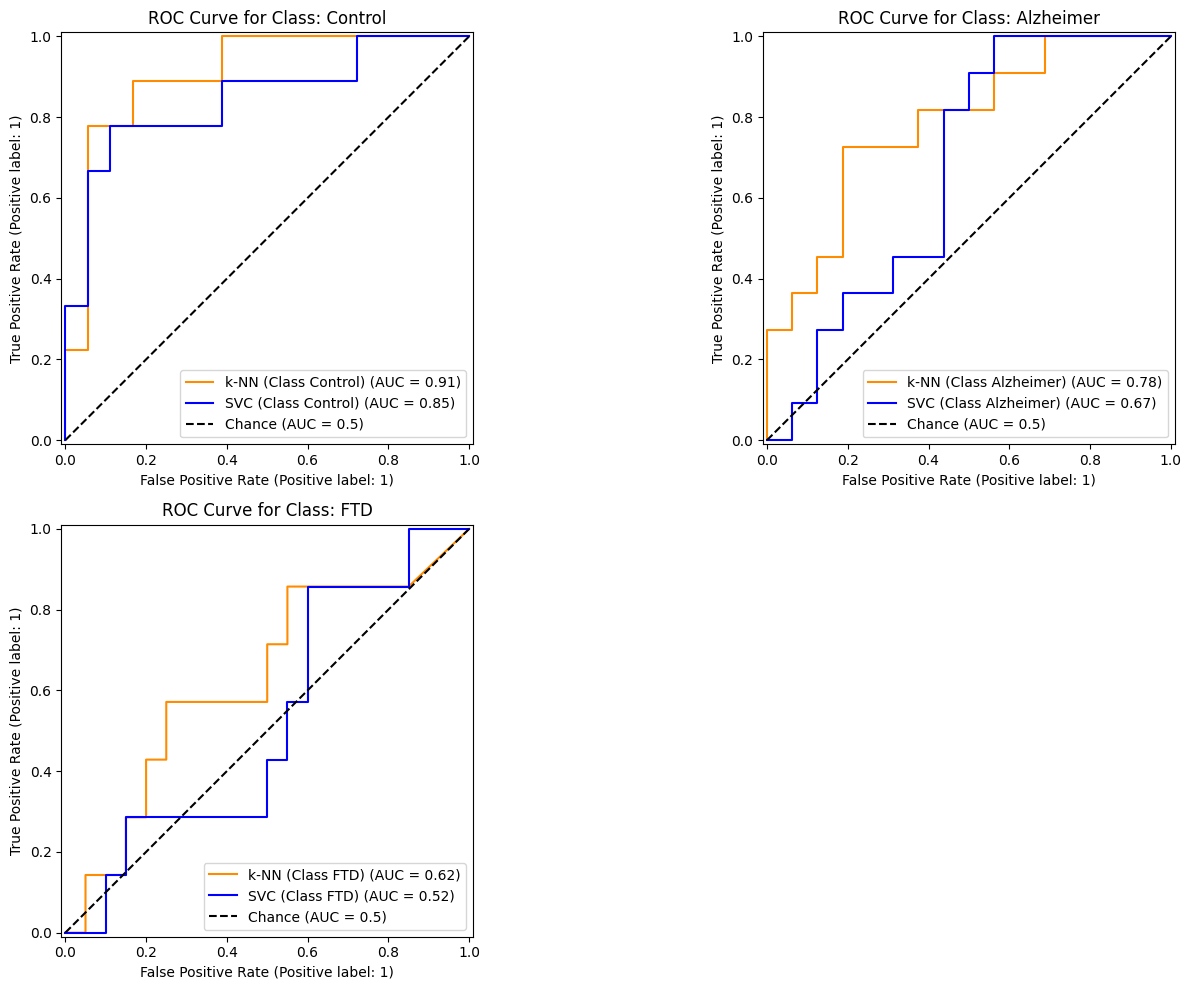

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay
from sklearn.preprocessing import label_binarize
import numpy as np

# Map original group names to numerical labels if not already done

class_names = ['Control', 'Alzheimer', 'FTD']
n_classes = len(class_names)

# Binarize the true labels for OvR plotting
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))

plt.figure(figsize=(15, 10))

# Plot ROC curve for each class
for i in range(n_classes):
    ax = plt.subplot(2, 2, i + 1) # Create subplots for each class

    # Plot k-NN ROC curve for current class
    RocCurveDisplay.from_predictions(
        y_test_binarized[:, i], # True binary labels for class i
        y_proba_knn_significant[:, i], # Predicted probabilities for class i from k-NN
        name=f'k-NN (Class {class_names[i]})',
        color='darkorange',
        ax=ax
    )

    # Plot SVC ROC curve for current class
    RocCurveDisplay.from_predictions(
        y_test_binarized[:, i],
        y_proba_svc_significant[:, i],
        name=f'SVC (Class {class_names[i]})',
        color='blue',
        ax=ax
    )

    ax.plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.5)') # Plot random chance line
    ax.set_title(f'ROC Curve for Class: {class_names[i]}')
    ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

In [17]:
print("psd")

psd
